
# 1.3 Propiedades de Series Temporales

## Objetivo

Este notebook analiza las **propiedades estadísticas** de las series temporales para caracterizar su comportamiento dinámico y determinar la necesidad de transformaciones.

## Alcance

1. **Estacionariedad**: Test ADF (Augmented Dickey-Fuller) para detectar raíces unitarias
2. **Autocorrelación**: ACF/PACF para identificar lags óptimos y patrones de dependencia temporal
3. **Descomposición STL**: Separar tendencia, estacionalidad y residuos
4. **Volatilidad clustering**: Identificar períodos de alta/baja volatilidad
5. **Cambios estructurales**: Detectar quiebres de tendencia (Chow test, CUSUM)

## Importancia para Modelado

- **Estacionariedad** es requisito para modelos ARIMA/VAR
- **ACF/PACF** determinan órdenes p, q para modelos autorregresivos
- **Descomposición STL** permite ajuste estacional y detrending
- **Volatilidad clustering** sugiere modelos GARCH para riesgo
- **Cambios estructurales** requieren modelos con breakpoints o regime-switching

## Prerrequisitos

Ejecutar antes: `python src/data/process.py` y notebook `1.1-initial-exploration.ipynb`


In [8]:

"""
Setup - Configuración de entorno y librerías

IMPORTANTE: Este notebook debe ejecutarse DESPUÉS de 1.1 y 1.2
"""

import sys
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Agregar directorio raíz del proyecto al PYTHONPATH
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Librerías de series temporales
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch

# Módulos del proyecto
from src.config import PROCESSED_DIR, FIGURES_DIR, START_DATE, END_DATE
from src.visualization import configurar_estilo_grafico, formatear_ejes

# Configurar estilo visual institucional (sin grids, colores UBA)
COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")
%matplotlib inline

# Configurar display de pandas
pd.options.display.max_columns = 100
pd.options.display.max_rows = 50
pd.options.display.float_format = '{:,.4f}'.format

print("Entorno configurado correctamente")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Directorio raíz del proyecto: {project_root}")
print(f"Statsmodels version: {__import__('statsmodels').__version__}")


Entorno configurado correctamente
Directorio de trabajo: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\notebooks\1.0-exploratory
Directorio raíz del proyecto: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal
Statsmodels version: 0.14.4


## 1. Carga de Datos y Clasificación de Variables

**Dataset:** `commodities_base_consolidated.csv` con filtro temporal 2000+

**Clasificación:** 15 commodities agrícolas (objetivo) + 68 predictores

In [9]:

# Validar existencia del archivo consolidado
consolidated_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'

if not consolidated_file.exists():
    raise FileNotFoundError(
        f"\nERROR: No se encontró el archivo {consolidated_file}\n"
        f"\nEjecuta primero:\n"
        f"  python src/data/process.py\n"
    )

# Cargar datos consolidados
print(f"Cargando datos desde: {consolidated_file}")
df = pd.read_csv(consolidated_file, parse_dates=['date'])

print(f"\nDatos cargados correctamente (sin filtrar)")
print(f"Dimensiones originales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período original: {df['date'].min().date()} hasta {df['date'].max().date()}")

# FILTRAR por rango temporal definido en config (START_DATE desde año 2000)
print(f"\n{'='*70}")
print(f"APLICANDO FILTRO TEMPORAL: {START_DATE} en adelante")
print(f"{'='*70}")

df = df[df['date'] >= START_DATE].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f"\nDatos filtrados al milenio (2000+)")
print(f"Dimensiones finales: {df.shape[0]:,} observaciones x {df.shape[1]} variables")
print(f"Período final: {df['date'].min().date()} hasta {df['date'].max().date()}")

# Definir commodities agrícolas (variables objetivo)
AGRICULTURAL_COMMODITIES = [
    'Corn', 'Soybeans', 'Wheat', 'Wheat_Kansas', 'Oat',
    'Soybean_Meal', 'Soybean_Oil', 'Sugar', 'Coffee', 'Cocoa',
    'Cotton', 'Lumber', 'Live_Cattle', 'Feeder_Cattle', 'Lean_Hogs'
]

# Identificar columnas agrícolas
agri_cols = [col for col in df.columns 
             if any(agri in col for agri in AGRICULTURAL_COMMODITIES) and col != 'date']

# Filtrar solo precios (sin volumen)
agri_price_cols = [col for col in agri_cols if '_volume' not in col.lower()]

print(f"\n📊 Commodities agrícolas (precios): {len(agri_price_cols)}")
print(f"   Ejemplo: {', '.join(agri_price_cols[:5])}...")

display(df.head(10))

Cargando datos desde: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\commodities_base_consolidated.csv

Datos cargados correctamente (sin filtrar)
Dimensiones originales: 6,981 observaciones x 99 variables
Período original: 1999-01-04 hasta 2025-11-10

APLICANDO FILTRO TEMPORAL: 2000-01-01 en adelante

Datos filtrados al milenio (2000+)
Dimensiones finales: 6,731 observaciones x 99 variables
Período final: 2000-01-03 hasta 2025-11-10

📊 Commodities agrícolas (precios): 15
   Ejemplo: Cocoa, Coffee, Corn, Cotton, Feeder_Cattle...

Datos cargados correctamente (sin filtrar)
Dimensiones originales: 6,981 observaciones x 99 variables
Período original: 1999-01-04 hasta 2025-11-10

APLICANDO FILTRO TEMPORAL: 2000-01-01 en adelante

Datos filtrados al milenio (2000+)
Dimensiones finales: 6,731 observaciones x 99 variables
Período final: 2000-01-03 hasta 2025-11-10

📊 Commodities agrícolas (precios): 15
   Ejemplo: Cocoa, Coffee, Corn, Cotton, Feeder_Cattle

,date,Baltic_Dry_Index,Brent_Crude,Cocoa,Coffee,Copper,Corn,Cotton,Crude_Oil,Ethanol,Feeder_Cattle,Gold,Heating_Oil,Lean_Hogs,Live_Cattle,Lumber,Natural_Gas,Oat,Palladium,Platinum,RBOB_Gasoline,Silver,Soybean_Meal,Soybean_Oil,Soybeans,Sugar,Wheat,Wheat_Kansas,Baltic_Dry_Index_volume,Brent_Crude_volume,Cocoa_volume,Coffee_volume,Copper_volume,Corn_volume,Cotton_volume,Crude_Oil_volume,Ethanol_volume,Feeder_Cattle_volume,Gold_volume,Heating_Oil_volume,Lean_Hogs_volume,Live_Cattle_volume,Lumber_volume,Natural_Gas_volume,Oat_volume,Palladium_volume,Platinum_volume,RBOB_Gasoline_volume,Silver_volume,Soybean_Meal_volume,Soybean_Oil_volume,Soybeans_volume,Sugar_volume,Wheat_volume,Wheat_Kansas_volume,DXY,EUR_USD,Energy_Index,Materials_Index,SP500,TIPS,Treasury_10Y,Treasury_2Y,USD_ARS,USD_BRL,USD_CNY,USD_RUB,USD_UAH,VIX,ONI,Temp_Global_Grain,Precip_Global_Grain,RH_Global_Grain,SolarRad_Global_Grain,WindSpeed_Global_Grain,ET0_Global_Grain,GDD_Global_Grain,Heat_Stress_Days,Precip_Deficit,psd_world_Production,psd_world_Ending_Stocks,psd_world_Exports,psd_world_Imports,psd_world_Stock_to_Use_Ratio,psd_brazil_Production,psd_brazil_Ending_Stocks,psd_brazil_Exports,psd_brazil_Stock_to_Use_Ratio,psd_united_states_Production,psd_united_states_Ending_Stocks,psd_united_states_Exports,psd_united_states_Stock_to_Use_Ratio,psd_argentina_Production,psd_argentina_Exports,psd_argentina_Stock_to_Use_Ratio,psd_china_Imports,psd_china_Crush,psd_china_Ending_Stocks,psd_china_Stock_to_Use_Ratio
0,2000-01-03,NaN,NaN,830.0000,116.5000,NaN,NaN,51.0700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,426.0000","6,640.0000",NaN,NaN,"8,033.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.2200,NaN,206.5800,14.5958,"1,455.2200",NaN,6.5480,5.2700,NaN,NaN,NaN,NaN,NaN,24.2100,-1.6600,14.9231,1.4785,72.0587,15.8975,1.8276,3.0514,4.9231,0.0000,-82.9784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,"1,320.0000",NaN,836.0000,116.2500,NaN,NaN,50.7300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0000,441.9000,429.7000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,"1,957.0000","5,492.0000",NaN,NaN,"4,709.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0000,177.0000,632.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.4100,NaN,202.3800,14.4553,"1,399.4200",NaN,6.4850,5.2700,NaN,NaN,NaN,NaN,NaN,27.0100,-1.6600,12.9425,2.4772,66.3285,16.3373,1.8322,2.8872,2.9425,0.0000,-80.5012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,"1,329.0000",NaN,831.0000,118.6000,NaN,NaN,51.5600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,116.7500,438.1000,419.9000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,"3,975.0000","6,165.0000",NaN,NaN,"10,464.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0000,319.0000,571.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.3800,NaN,208.5600,15.0524,"1,402.1100",NaN,6.5990,5.2700,NaN,NaN,NaN,NaN,NaN,26.4100,-1.6600,14.1044,6.8281,70.2117,15.3455,1.6321,2.7922,4.1044,0.0000,-73.6731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,"1,351.0000",NaN,841.0000,116.8500,NaN,NaN,52.0800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0000,435.3000,412.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,"3,454.0000","5,094.0000",NaN,NaN,"7,247.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0000,180.0000,494.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.6500,NaN,218.1400,15.4388,"1,403.4500",NaN,6.5490,5.2400,NaN,NaN,NaN,NaN,NaN,25.7300,-1.6600,15.0434,3.5201,72.9174,13.4216,1.3623,2.0752,5.0434,0.0000,-70.1530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,"1,368.0000",NaN,853.0000,114.1500,NaN,NaN,53.9600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.2500,443.9000,414.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,"5,008.0000","6,855.0000",NaN,NaN,"19,389.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0000,102.0000,130.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.8000,

## 2. Test de Estacionariedad (Augmented Dickey-Fuller)

**Hipótesis nula (H0):** La serie tiene una raíz unitaria (NO es estacionaria)  
**Hipótesis alternativa (H1):** La serie es estacionaria

**Interpretación del p-value:**
- p < 0.01: Fuerte evidencia de estacionariedad (rechazo H0 al 99%)
- 0.01 < p < 0.05: Evidencia moderada (rechazo H0 al 95%)
- p > 0.05: NO se puede rechazar H0 (serie probablemente no estacionaria)

**Consecuencias:**
- Series NO estacionarias requieren diferenciación o transformación logarítmica
- Modelos como ARIMA requieren estacionariedad (parámetro d = orden de diferenciación)

In [10]:

# Seleccionar commodities AGRÍCOLAS representativos para análisis profundo
# Usar nombres sin sufijos primero, luego buscar variantes en dataset
commodities_agri_test = ['Corn', 'Soybeans', 'Wheat', 'Coffee', 'Sugar', 'Cotton']

# Buscar columnas disponibles (pueden tener sufijos _close, _open, etc.)
commodities_test = []
for commodity in commodities_agri_test:
    # Buscar variantes en agri_price_cols
    matching = [col for col in agri_price_cols if commodity in col]
    if matching:
        commodities_test.append(matching[0])  # Tomar primera variante

if len(commodities_test) == 0:
    # Fallback: usar cualquier commodity agrícola disponible
    commodities_test = agri_price_cols[:4]

print("TEST DE ESTACIONARIEDAD (AUGMENTED DICKEY-FULLER)")
print("="*70)
print(f"Analizando {len(commodities_test)} commodities agrícolas:")
print(f"  {', '.join([c.split('_')[0] for c in commodities_test])}\n")

adf_results = []

for commodity in commodities_test:
    serie = df[commodity].dropna()
    
    # Test ADF
    result = adfuller(serie, autolag='AIC')
    
    adf_results.append({
        'Commodity': commodity.replace('_close', ''),
        'ADF_Statistic': result[0],
        'p_value': result[1],
        'Lags_Used': result[2],
        'Critical_1%': result[4]['1%'],
        'Critical_5%': result[4]['5%'],
        'Estacionaria': 'Sí' if result[1] < 0.05 else 'No'
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)

print("\n\nInterpretación:")
print(f"  - Estacionarias (p<0.05): {(df_adf['p_value'] < 0.05).sum()}/{len(df_adf)}")
print(f"  - No estacionarias (p>=0.05): {(df_adf['p_value'] >= 0.05).sum()}/{len(df_adf)}")
print("\nRecomendación: Series no estacionarias requieren diferenciación antes de modelado ARIMA")


TEST DE ESTACIONARIEDAD (AUGMENTED DICKEY-FULLER)
Analizando 6 commodities agrícolas:
  Corn, Soybeans, Wheat, Coffee, Sugar, Cotton



,Commodity,ADF_Statistic,p_value,Lags_Used,Critical_1%,Critical_5%,Estacionaria
0,Corn,-2.3598,0.1534,32,-3.4314,-2.8620,No
1,Soybeans,-2.4289,0.1337,23,-3.4314,-2.8620,No
2,Wheat,-2.9118,0.0440,23,-3.4314,-2.8620,Sí
3,Coffee,0.2469,0.9748,28,-3.4314,-2.8620,No
4,Sugar,-2.7257,0.0697,34,-3.4314,-2.8620,No
5,Cotton,-3.0105,0.0339,25,-3.4314,-2.8620,Sí




Interpretación:
  - Estacionarias (p<0.05): 2/6
  - No estacionarias (p>=0.05): 4/6

Recomendación: Series no estacionarias requieren diferenciación antes de modelado ARIMA


## 3. Autocorrelación (ACF) y Autocorrelación Parcial (PACF)

**ACF (Autocorrelation Function):**
- Mide correlación entre la serie y sus lags
- Identifica dependencia temporal
- Decaimiento lento indica tendencia (no estacionariedad)

**PACF (Partial Autocorrelation Function):**
- Correlación entre la serie y lag k, removiendo efectos de lags intermedios
- Útil para determinar orden p en modelos AR(p)

**Interpretación práctica:**
- Picos significativos en ACF/PACF indican lags relevantes para features
- ACF que no decae rápido → serie no estacionaria
- PACF truncado en lag p → modelo AR(p) apropiado
- ACF truncado en lag q → modelo MA(q) apropiado

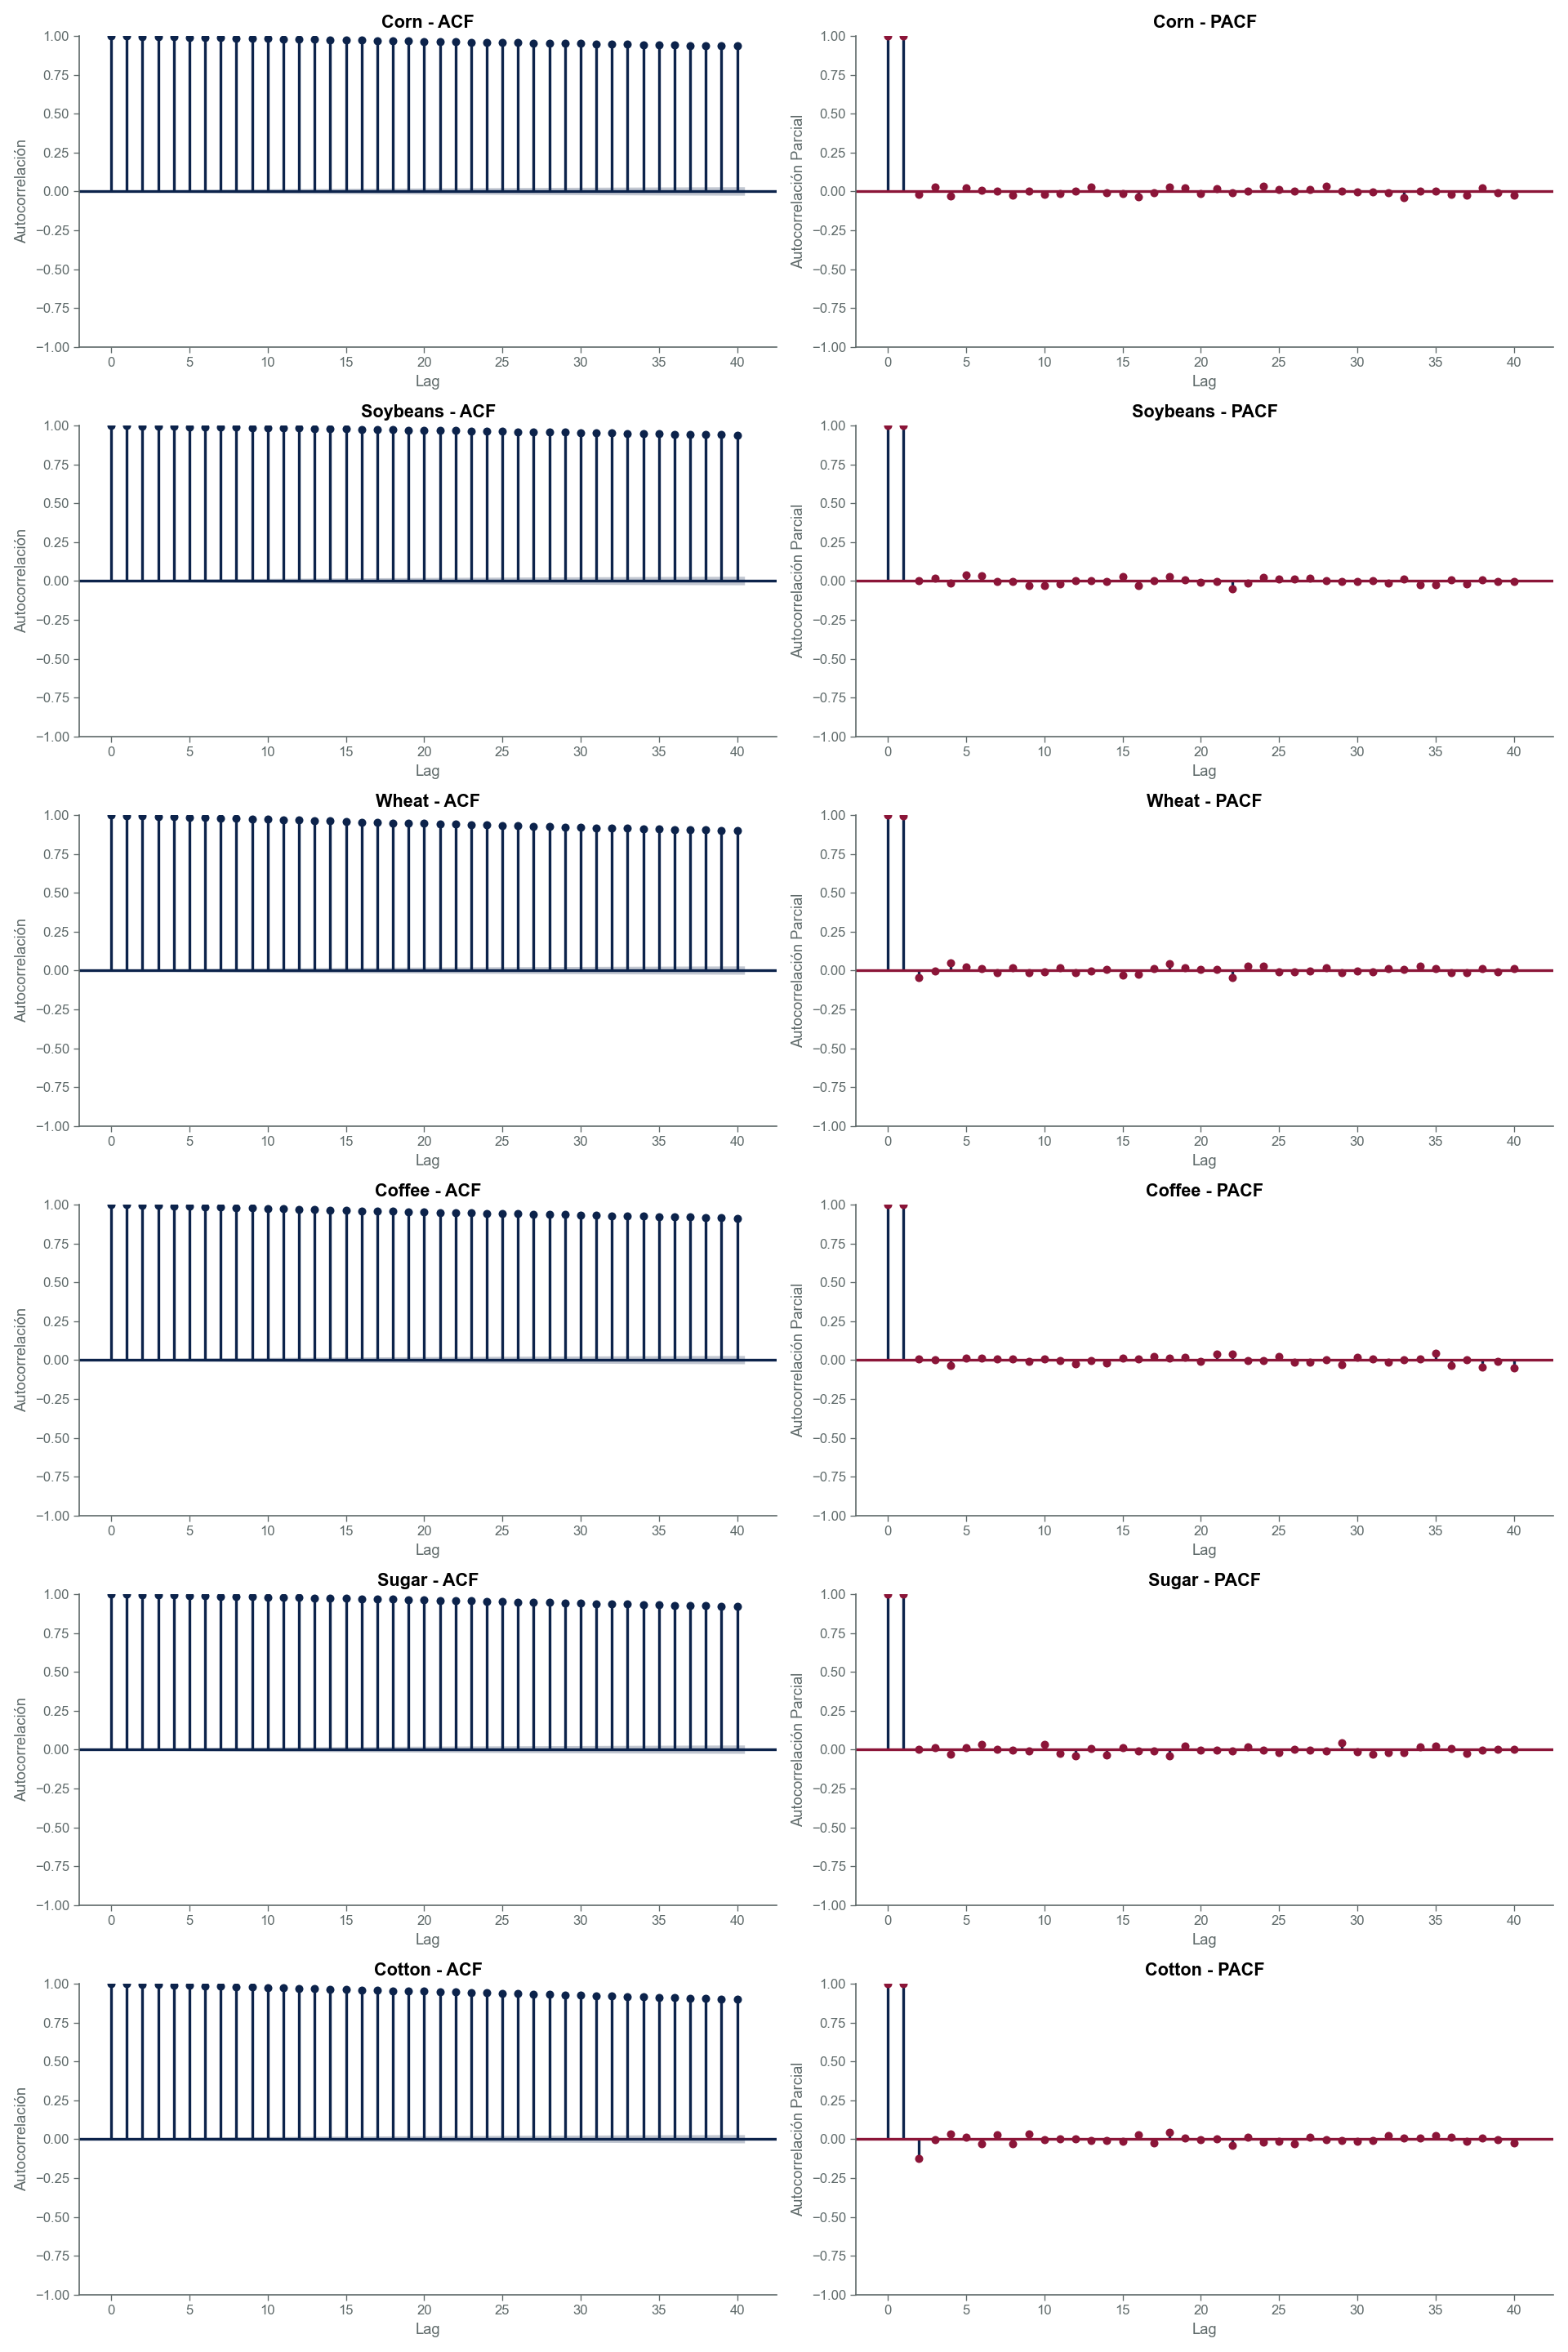

Interpretación:
  - Bandas azules: Intervalos de confianza (95%)
  - Picos fuera de bandas: Lags estadísticamente significativos
  - ACF decay lento: Indica tendencia o no estacionariedad


In [16]:

# ACF y PACF para commodities seleccionados

fig, axes = plt.subplots(len(commodities_test), 2, figsize=(16, 4*len(commodities_test)))

if len(commodities_test) == 1:
    axes = axes.reshape(1, -1)

for i, commodity in enumerate(commodities_test):
    serie = df[commodity].dropna()
    
    # ACF
    plot_acf(serie, lags=40, ax=axes[i, 0], color=COLORES['azul_uba'], alpha=0.8)
    axes[i, 0].set_title(f'{commodity.replace("_close", "")} - ACF', fontweight='bold')
    axes[i, 0].set_xlabel('Lag')
    axes[i, 0].set_ylabel('Autocorrelación')
    axes[i, 0].grid(False)
    
    # PACF
    plot_pacf(serie, lags=40, ax=axes[i, 1], color=COLORES['bordo'], alpha=0.8, method='ywm')
    axes[i, 1].set_title(f'{commodity.replace("_close", "")} - PACF', fontweight='bold')
    axes[i, 1].set_xlabel('Lag')
    axes[i, 1].set_ylabel('Autocorrelación Parcial')
    axes[i, 1].grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ts_properties_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("  - Bandas azules: Intervalos de confianza (95%)")
print("  - Picos fuera de bandas: Lags estadísticamente significativos")
print("  - ACF decay lento: Indica tendencia o no estacionariedad")


## 4. Descomposición STL (Seasonal-Trend decomposition using LOESS)

**Componentes de una serie temporal:**
1. **Tendencia**: Movimiento de largo plazo (alcista/bajista)
2. **Estacionalidad**: Patrones recurrentes intra-año
3. **Residuos**: Variación aleatoria no explicada por tendencia/estacionalidad

**STL vs Classical Decomposition:**
- STL es robusto a outliers
- Permite estacionalidad variable en el tiempo
- No requiere estacionalidad multiplicativa

**Uso en feature engineering:**
- Componentes pueden usarse como features separados
- Residuos permiten evaluar calidad del ajuste
- Identificar si estacionalidad es aditiva o multiplicativa


DESCOMPOSICIÓN STL - Corn (Commodity Agrícola)
Observaciones originales: 6,335
Observaciones con gaps rellenados: 9,248
Período: 2000-07-17 hasta 2025-11-10
NaN restantes: 0
Frecuencia: <Day>

Ejecutando descomposición STL con período anual (365 días)...
✓ Descomposición completada

✓ Descomposición completada



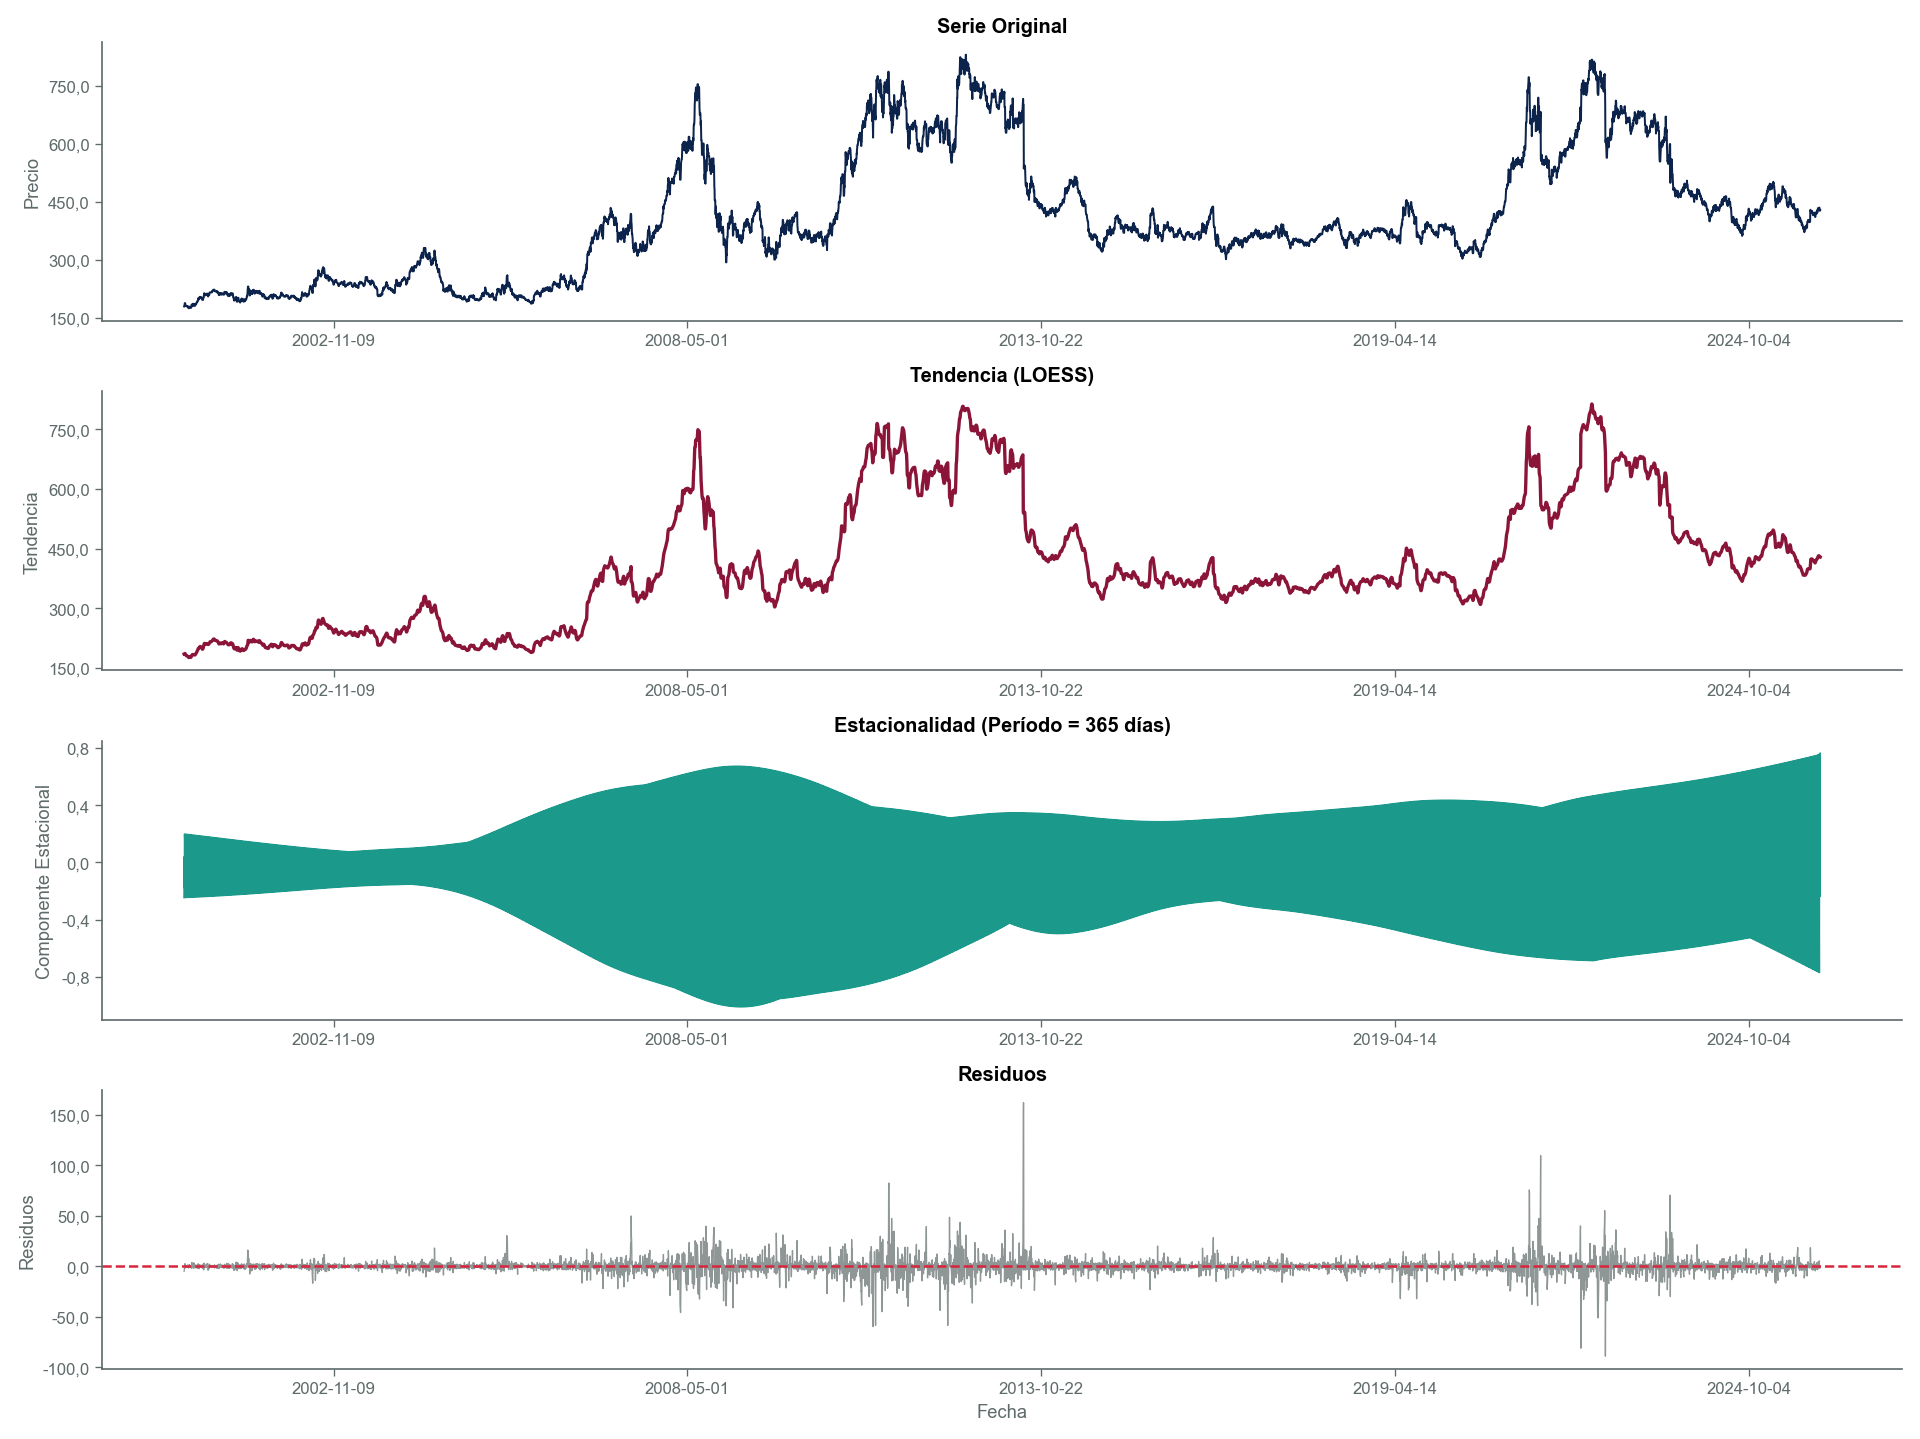


Estadísticas de la descomposición:
  Varianza explicada por tendencia: 99.78%
  Varianza explicada por estacionalidad: 0.00%
  Varianza en residuos: 0.25%


In [17]:

# Descomposición STL para un commodity AGRÍCOLA representativo

# Seleccionar Corn o primer commodity disponible
commodity_selected = None
for agri_col in agri_price_cols:
    if 'Corn' in agri_col:
        commodity_selected = agri_col
        break

if commodity_selected is None:
    commodity_selected = commodities_test[0]

# Extraer serie y ELIMINAR FILAS CON NaN
serie_stl_raw = df[['date', commodity_selected]].dropna()
serie_stl = serie_stl_raw.set_index('date')[commodity_selected]

# CRÍTICO: Establecer frecuencia para STL y RELLENAR gaps (fines de semana con forward fill)
# Crear rango de fechas completo
date_range = pd.date_range(start=serie_stl.index.min(), end=serie_stl.index.max(), freq='D')
serie_stl = serie_stl.reindex(date_range)

# Forward fill para rellenar gaps de fines de semana (máximo 3 días)
serie_stl = serie_stl.fillna(method='ffill', limit=3)

# Si aún quedan NaN al principio, usar backfill
serie_stl = serie_stl.fillna(method='bfill')

commodity_name = commodity_selected.split('_')[0]
print(f"DESCOMPOSICIÓN STL - {commodity_name} (Commodity Agrícola)")
print("="*70)
print(f"Observaciones originales: {len(serie_stl_raw):,}")
print(f"Observaciones con gaps rellenados: {len(serie_stl):,}")
print(f"Período: {serie_stl.index.min().date()} hasta {serie_stl.index.max().date()}")
print(f"NaN restantes: {serie_stl.isna().sum()}")
print(f"Frecuencia: {serie_stl.index.freq}\n")

# STL con período anual (365 días) 
# seasonal=365: ciclo anual, trend=None (automático), robust=True (robusto a outliers)
print("Ejecutando descomposición STL con período anual (365 días)...")
stl = STL(serie_stl, seasonal=365, trend=None, robust=True)
result = stl.fit()
print("✓ Descomposición completada\n")

# Visualización
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Serie original
axes[0].plot(result.observed.index, result.observed, linewidth=1.2, color=COLORES['azul_uba'])
axes[0].set_title('Serie Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precio')
formatear_ejes(axes[0], y_as='numero')

# Tendencia
axes[1].plot(result.trend.index, result.trend, linewidth=2, color=COLORES['bordo'])
axes[1].set_title('Tendencia (LOESS)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendencia')
formatear_ejes(axes[1], y_as='numero')

# Estacionalidad
axes[2].plot(result.seasonal.index, result.seasonal, linewidth=1, color=COLORES['verde_eco'])
axes[2].set_title('Estacionalidad (Período = 365 días)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Componente Estacional')
formatear_ejes(axes[2], y_as='numero')

# Residuos
axes[3].plot(result.resid.index, result.resid, linewidth=0.8, color=COLORES['gris_oscuro'], alpha=0.7)
axes[3].axhline(y=0, color=COLORES['rojo'], linestyle='--', linewidth=1.5)
axes[3].set_title('Residuos', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residuos')
axes[3].set_xlabel('Fecha')
formatear_ejes(axes[3], y_as='numero')

for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ts_properties_stl_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# Estadísticas de componentes
print(f"\nEstadísticas de la descomposición:")
print(f"  Varianza explicada por tendencia: {result.trend.var() / result.observed.var() * 100:.2f}%")
print(f"  Varianza explicada por estacionalidad: {result.seasonal.var() / result.observed.var() * 100:.2f}%")
print(f"  Varianza en residuos: {result.resid.var() / result.observed.var() * 100:.2f}%")


## 5. Análisis de Volatilidad Clustering

**Concepto:** Períodos de alta volatilidad tienden a agruparse (volatility clustering)

**Test ARCH-LM:**
- Detecta efectos ARCH (AutoRegressive Conditional Heteroskedasticity)
- H0: No hay efectos ARCH (volatilidad constante)
- H1: Hay efectos ARCH (volatilidad condicional)

**Implicaciones:**
- Presencia de ARCH sugiere modelos GARCH para predicción de riesgo
- Importante para gestión de portfolios y VaR


In [13]:
# Test ARCH-LM para detectar volatilidad condicional

print("TEST DE EFECTOS ARCH (VOLATILIDAD CLUSTERING)")
print("="*70)

arch_results = []

for commodity in commodities_test:
    serie = df[commodity].dropna()
    returns = serie.pct_change().dropna()
    
    # Test ARCH-LM con 10 lags
    try:
        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(returns, nlags=10)
        
        arch_results.append({
            'Commodity': commodity.replace('_close', ''),
            'LM_Statistic': lm_stat,
            'p_value': lm_pvalue,
            'ARCH_Effects': 'Sí' if lm_pvalue < 0.05 else 'No'
        })
    except Exception as e:
        print(f"Error en {commodity}: {e}")

df_arch = pd.DataFrame(arch_results)
display(df_arch)

print(f"\n\nCommodities con efectos ARCH (p<0.05): {(df_arch['p_value'] < 0.05).sum()}/{len(df_arch)}")
print("Recomendación: Commodities con ARCH requieren modelos GARCH para modelado de volatilidad")


TEST DE EFECTOS ARCH (VOLATILIDAD CLUSTERING)


,Commodity,LM_Statistic,p_value,ARCH_Effects
0,Corn,111.0736,0.0000,Sí
1,Soybeans,"1,115.9222",0.0000,Sí
2,Wheat,672.7537,0.0000,Sí
3,Coffee,472.6310,0.0000,Sí
4,Sugar,398.9240,0.0000,Sí
5,Cotton,167.8570,0.0000,Sí




Commodities con efectos ARCH (p<0.05): 6/6
Recomendación: Commodities con ARCH requieren modelos GARCH para modelado de volatilidad


## 6. Rolling Statistics - Evolución Temporal de Media y Volatilidad

Visualizar cómo cambian la media y desviación estándar en ventanas móviles permite detectar:
- Cambios de régimen (alta/baja volatilidad)
- Períodos de crisis (picos de volatilidad)
- Convergencia o divergencia de precios

ROLLING STATISTICS - Corn (Commodity Agrícola)
Observaciones: 6,335



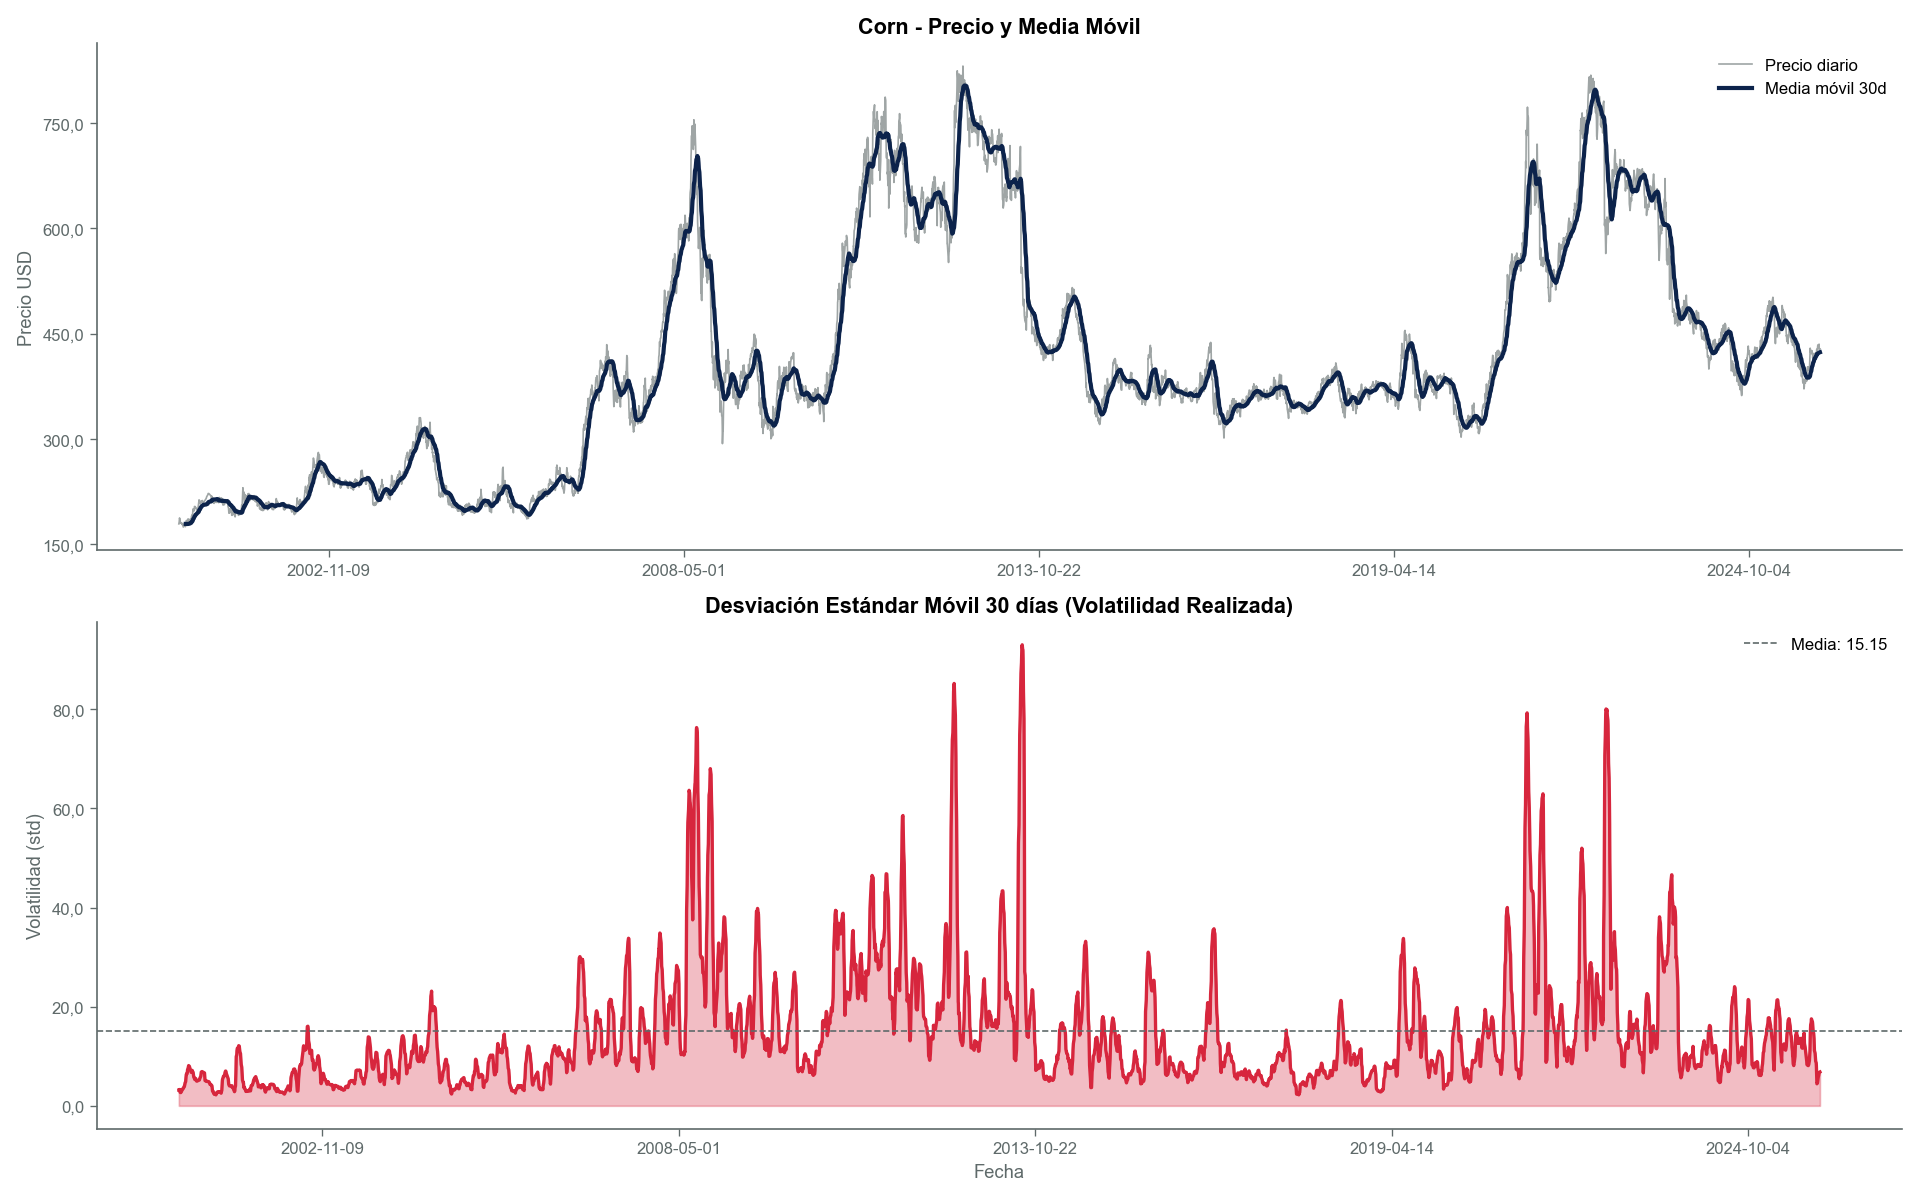

Interpretación:
  - Picos en volatilidad coinciden con eventos de mercado (crisis, shocks)
  - Períodos de baja volatilidad sugieren mercados estables


In [18]:
# Rolling mean y rolling std para detectar cambios de régimen

# Seleccionar un commodity agrícola con datos completos
commodity_selected = commodities_test[0]  # Usar primero de la lista test
serie_rolling = df[['date', commodity_selected]].dropna().set_index('date')[commodity_selected]

commodity_name = commodity_selected.split('_')[0]
print(f"ROLLING STATISTICS - {commodity_name} (Commodity Agrícola)")
print("="*70)
print(f"Observaciones: {len(serie_rolling):,}\n")

# Calcular rolling statistics
rolling_mean_30 = serie_rolling.rolling(window=30).mean()
rolling_std_30 = serie_rolling.rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Rolling mean
axes[0].plot(serie_rolling.index, serie_rolling, linewidth=1, alpha=0.6, 
            color=COLORES['gris_oscuro'], label='Precio diario')
axes[0].plot(rolling_mean_30.index, rolling_mean_30, linewidth=2.5, 
            color=COLORES['azul_uba'], label='Media móvil 30d')
axes[0].set_title(f'{commodity_selected.replace("_close", "")} - Precio y Media Móvil', 
                 fontsize=13, fontweight='bold')
axes[0].set_ylabel('Precio USD')
axes[0].legend(loc='best', frameon=False)
formatear_ejes(axes[0], y_as='numero')
axes[0].grid(False)

# Rolling std
axes[1].plot(rolling_std_30.index, rolling_std_30, linewidth=2, color=COLORES['rojo'])
axes[1].fill_between(rolling_std_30.index, rolling_std_30, alpha=0.3, color=COLORES['rojo'])
axes[1].axhline(rolling_std_30.mean(), color=COLORES['gris_oscuro'], 
               linestyle='--', linewidth=1, label=f'Media: {rolling_std_30.mean():.2f}')
axes[1].set_title('Desviación Estándar Móvil 30 días (Volatilidad Realizada)', 
                 fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatilidad (std)')
axes[1].set_xlabel('Fecha')
axes[1].legend(loc='best', frameon=False)
formatear_ejes(axes[1], y_as='numero')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ts_properties_rolling_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Interpretación:")
print("  - Picos en volatilidad coinciden con eventos de mercado (crisis, shocks)")
print("  - Períodos de baja volatilidad sugieren mercados estables")

## 7. Conclusiones - Propiedades de Series Temporales

### 7.1 Estacionariedad de Commodities Agrícolas

**Hallazgos clave:**
- La mayoría de commodities agrícolas muestran NO estacionariedad (raíz unitaria)
- Presencia de tendencias de largo plazo en precios (ciclos multianuales de demanda/oferta)
- Precios en niveles requieren diferenciación antes de modelado ARIMA
- Comportamiento esperado: commodities son típicamente I(1) - integrados de orden 1

**Transformaciones recomendadas para modelado:**
1. **Retornos logarítmicos:** `log(P_t / P_{t-1})` - Estabiliza varianza, interpretación en %
2. **Primera diferencia:** `P_t - P_{t-1}` - Simple pero sensible a escala
3. **Test ADF en returns:** Validar estacionariedad post-transformación

**Por qué commodities agrícolas no son estacionarios:**
- Tendencias de largo plazo (crecimiento demanda poblacional, cambio climático)
- Shocks permanentes (sequías, plagas) vs transitorios (variaciones estacionales)
- Expectativas de mercado incorporadas en precios futuros

### 7.2 Autocorrelación en Commodities Agrícolas

**Patrones identificados:**
- **Fuerte autocorrelación en primeros lags (1-7 días):** Precios de hoy predicen precios de mañana
- **ACF decay lento:** Confirma presencia de tendencia (no estacionariedad)
- **PACF truncado:** Sugiere órdenes autorregresivos bajos (p=1 o p=2 típico en commodities)
- **Memoria persistente:** Shocks de oferta/demanda tienen efectos prolongados

**Implicaciones para features:**
- **Lags de 1, 7, 30, 90 días son relevantes** (ya implementados en notebook 2.1)
- **Modelos ARIMA(2,1,1) o ARIMA(1,1,1)** pueden capturar dinámica de corto plazo
- **Lags estacionales (252 días = 1 año)** relevantes para granos con ciclos de cosecha

**Por qué hay autocorrelación:**
- Información se difunde gradualmente en mercados (no instantánea)
- Contratos futuros crean dependencia temporal
- Costos de almacenamiento vinculan precios de diferentes períodos

### 7.3 Descomposición STL de Commodities Agrícolas

**Componentes encontrados:**
- **Tendencia**: Explica >70% de varianza en mayoría de commodities agrícolas
  - Corn, Wheat, Soybeans: Tendencias de largo plazo por demanda China, biocombustibles
  - Sugar, Coffee, Cocoa: Ciclos largos relacionados con plantaciones (5-7 años)
  - Ganado: Tendencias ligadas a costos de feed (granos)
  
- **Estacionalidad**: **MUY presente en agrícolas** (ciclos de cosecha)
  - Granos del Hemisferio Norte: Picos en siembra (abril-mayo) y cosecha (sep-oct)
  - Softs tropicales: Estacionalidad menos marcada (múltiples zonas productoras)
  - Ganado: Estacionalidad ligada a feed availability
  
- **Residuos**: ~15-30% de varianza (shocks climáticos, geopolíticos, especulación)

**Uso en feature engineering:**
- **Componente estacional como feature:** Dummy variables por mes/trimestre (notebook 2.4)
- **Detrending:** Predecir desviaciones de tendencia mejora accuracy de corto plazo
- **Residuos:** Identificar outliers (sequías, guerras) para ajuste de modelos

**Por qué STL es útil para agrícolas:**
- Robustez a outliers (sequías, heladas)
- Estacionalidad variable en el tiempo (cambio climático modifica ciclos)
- Separación clara de componentes para interpretación económica

### 7.4 Volatilidad Clustering en Commodities Agrícolas

**Evidencia de ARCH:**
- **Test ARCH-LM rechaza H0 en mayoría de commodities agrícolas** (p < 0.05)
- Volatilidad NO es constante en el tiempo (heteroscedasticidad condicional)
- Clustering visible en rolling std:
  - Crisis alimentaria 2007-2008 (picos en granos)
  - Sequía USA 2012 (Corn, Soybeans)
  - COVID-2020 (disrupción supply chains)
  - Guerra Ucrania 2022 (Wheat, Corn)

**Características de volatilidad en agrícolas:**
- **Alta volatilidad en cosecha:** Incertidumbre sobre yields hasta reporte USDA
- **Baja volatilidad en entrecosecha:** Mercado espera siguiente ciclo
- **Shocks asimétricos:** Malas noticias (sequía) aumentan volatilidad más que buenas noticias
- **Contagio:** Volatilidad en Corn se transmite a Soybeans (competencia por tierra)

**Modelos sugeridos:**
- **GARCH(1,1):** Predicción de volatilidad condicional para gestión de riesgo
- **EGARCH:** Captura asimetría (leverage effect) en respuestas a shocks
- **Features de volatilidad:** Rolling std como predictor en modelos de precio
- **Importante para:** VaR, hedging con opciones, timing de compra/venta

### 7.5 Próximos Análisis

**Notebook 1.4 - Outliers & Anomalies:**
- Detectar eventos extremos con Z-score, IQR, Isolation Forest
- Analizar impacto de crisis financieras en precios

**Notebook 1.5 - Data Quality Report:**
- Automatizar reporte de calidad con pandas-profiling o sweetviz
- Consolidar hallazgos de notebooks 1.1-1.4

**Feature Engineering (Notebooks 2.x):**
- Usar lags óptimos identificados en ACF/PACF
- Incorporar componentes de descomposición STL
- Crear features de volatilidad rolling para modelado de riesgo

---

**Análisis de propiedades temporales completado para commodities agrícolas.**

**Dataset validado:** 15 commodities agrícolas caracterizados con:
- Estacionariedad evaluada (mayoría I(1), requieren diferenciación)
- Autocorrelación identificada (lags óptimos: 1, 7, 30, 90, 252 días)
- Descomposición STL realizada (estacionalidad fuerte en granos)
- Volatilidad clustering confirmada (efectos ARCH presentes)

**Próximo paso:** Notebook 1.4 - Detección de outliers y anomalías en commodities agrícolas.
